Objective:
Apply your knowledge of NumPy, Pandas, and Matplotlib to analyze a real-world dataset. Utilize advanced statistical functions and array operations in NumPy, and integrate these with Pandas for data manipulation and Matplotlib for visualization.



Dataset:
You will work with the “Global Power Plant Database” provided by the World Resources Institute, which contains detailed information about power plants worldwide. This dataset is ideal for practicing array manipulations, statistical analysis, and time series data handling.

Download the dataset here.

or you can download it directly

Here.



Tasks:
Data Import and Cleaning:

Import the dataset using Pandas.
Identify missing values and handle them appropriately.
Use NumPy to convert relevant columns to numerical types if necessary.
Exploratory Data Analysis:

Utilize Pandas to summarize key statistics (mean, median, standard deviation) for numerical columns.
Explore the distribution of power plants by country and fuel type.
Statistical Analysis:

Perform a statistical analysis of power output by fuel type using NumPy’s statistical functions.
Use hypothesis testing to determine if the mean power output differs significantly between different fuel types.
Time Series Analysis:

If the dataset includes time-related data (like year of establishment), use NumPy to analyze trends over time.
Explore how the mix of fuel types for power generation has evolved over the years.
Advanced Visualization:

Create visualizations using Matplotlib and Seaborn to illustrate your findings.
Consider plotting the geographical distribution of power plants using latitude and longitude data, if available.
Matrix Operations in Real-World Context:

Demonstrate matrix operations by analyzing relationships between different attributes (e.g., fuel type, capacity, and geographic location).
Discuss the relevance of eigenvectors and eigenvalues in this context.
Integrating NumPy with Pandas and Matplotlib:

Show how NumPy can be used to enhance data manipulation in Pandas and data visualization in Matplotlib.
Provide examples, such as using NumPy arrays for complex filtering in Pandas or for creating sophisticated plots in Matplotlib.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("global_power_plant_database.csv")

df.head()

/var/folders/lk/70k7s7qj5dg4ly834qvdm7240000gn/T/ipykernel_98875/2437092554.py:1: DtypeWarning: Columns (0: other_fuel3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("global_power_plant_database.csv")


,country,country_long,name,gppd_idnr,capacity_mw,latitude,longitude,primary_fuel,other_fuel1,other_fuel2,...,estimated_generation_gwh_2013,estimated_generation_gwh_2014,estimated_generation_gwh_2015,estimated_generation_gwh_2016,estimated_generation_gwh_2017,estimated_generation_note_2013,estimated_generation_note_2014,estimated_generation_note_2015,estimated_generation_note_2016,estimated_generation_note_2017
0,AFG,Afghanistan,Kajaki Hydroelectric Power Plant Afghanistan,GEODB0040538,33.0,32.322,65.1190,Hydro,NaN,NaN,...,123.77,162.90,97.39,137.76,119.50,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
1,AFG,Afghanistan,Kandahar DOG,WKS0070144,10.0,31.670,65.7950,Solar,NaN,NaN,...,18.43,17.48,18.25,17.70,18.29,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE
2,AFG,Afghanistan,Kandahar JOL,WKS0071196,10.0,31.623,65.7920,Solar,NaN,NaN,...,18.64,17.58,19.10,17.62,18.72,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE
3,AFG,Afghanistan,Mahipar Hydroelectric Power Plant Afghanistan,GEODB0040541,66.0,34.556,69.4787,Hydro,NaN,NaN,...,225.06,203.55,146.90,230.18,174.91,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
4,AFG,Afghanistan,Naghlu Dam Hydroelectric Power Plant Afghanistan,GEODB0040534,100.0,34.641,69.7170,Hydro,NaN,NaN,...,406.16,357.22,270.99,395.38,350.80,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1


## Data Cleaning

In [3]:
df.shape

(34936, 36)

In [4]:
df.columns

Index(['country', 'country_long', 'name', 'gppd_idnr', 'capacity_mw',
       'latitude', 'longitude', 'primary_fuel', 'other_fuel1', 'other_fuel2',
       'other_fuel3', 'commissioning_year', 'owner', 'source', 'url',
       'geolocation_source', 'wepp_id', 'year_of_capacity_data',
       'generation_gwh_2013', 'generation_gwh_2014', 'generation_gwh_2015',
       'generation_gwh_2016', 'generation_gwh_2017', 'generation_gwh_2018',
       'generation_gwh_2019', 'generation_data_source',
       'estimated_generation_gwh_2013', 'estimated_generation_gwh_2014',
       'estimated_generation_gwh_2015', 'estimated_generation_gwh_2016',
       'estimated_generation_gwh_2017', 'estimated_generation_note_2013',
       'estimated_generation_note_2014', 'estimated_generation_note_2015',
       'estimated_generation_note_2016', 'estimated_generation_note_2017'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 34936 entries, 0 to 34935
Data columns (total 36 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   country                         34936 non-null  str    
 1   country_long                    34936 non-null  str    
 2   name                            34936 non-null  str    
 3   gppd_idnr                       34936 non-null  str    
 4   capacity_mw                     34936 non-null  float64
 5   latitude                        34936 non-null  float64
 6   longitude                       34936 non-null  float64
 7   primary_fuel                    34936 non-null  str    
 8   other_fuel1                     1944 non-null   str    
 9   other_fuel2                     276 non-null    str    
 10  other_fuel3                     92 non-null     str    
 11  commissioning_year              17447 non-null  float64
 12  owner                           20868 non-n

In [6]:
df.describe()

,capacity_mw,latitude,longitude,commissioning_year,year_of_capacity_data,generation_gwh_2013,generation_gwh_2014,generation_gwh_2015,generation_gwh_2016,generation_gwh_2017,generation_gwh_2018,generation_gwh_2019,estimated_generation_gwh_2013,estimated_generation_gwh_2014,estimated_generation_gwh_2015,estimated_generation_gwh_2016,estimated_generation_gwh_2017
count,34936.000000,34936.000000,34936.000000,17447.000000,14887.000000,6417.000000,7226.000000,8203.000000,9144.000000,9500.000000,9637.000000,9659.000000,16120.000000,16503.000000,17050.000000,17570.000000,33138.000000
mean,163.355148,32.816637,-6.972803,1997.414823,2018.218849,592.696107,656.863891,762.368840,693.149763,661.834161,517.320785,423.922436,239.112221,242.431122,235.866067,235.695265,716.443378
std,489.636072,22.638603,78.405850,23.397835,1.606428,2174.833482,2231.464288,2533.459828,2404.516759,2369.296957,1975.302686,1698.506485,1191.258172,1285.798297,1267.005223,1259.559841,2484.361200
min,1.000000,-77.847000,-179.977700,1896.000000,2000.000000,-947.600000,-989.619000,-864.428000,-768.620000,-934.944000,-982.622000,-780.339000,1.120000,0.870000,0.440000,0.300000,0.000000
25%,4.900000,29.256475,-77.641550,1988.000000,2017.000000,1.947000,2.260000,2.664500,2.729000,2.467000,2.242000,2.751500,8.620000,8.680000,8.380000,8.322500,8.180000
50%,16.745000,39.727750,-2.127100,2007.000000,2019.000000,23.426000,23.608500,26.142000,22.462389,17.876500,12.530000,11.530000,27.620000,28.250000,26.830000,27.555000,37.590000
75%,75.344250,46.263125,49.502675,2014.000000,2019.000000,199.706000,226.322250,285.862583,249.866750,214.505150,151.117000,122.781498,106.805000,106.980000,103.120000,107.237500,229.565000
max,22500.000000,71.292000,179.388700,2020.000000,2019.000000,50834.000000,32320.917000,37433.607000,32377.477000,36448.643000,35136.000000,31920.368000,48675.060000,58470.770000,57113.350000,60859.730000,82810.770000


In [7]:
df.isnull().sum()

country                               0
country_long                          0
name                                  0
gppd_idnr                             0
capacity_mw                           0
latitude                              0
longitude                             0
primary_fuel                          0
other_fuel1                       32992
other_fuel2                       34660
other_fuel3                       34844
commissioning_year                17489
owner                             14068
source                               15
url                                  18
geolocation_source                  419
wepp_id                           18702
year_of_capacity_data             20049
generation_gwh_2013               28519
generation_gwh_2014               27710
generation_gwh_2015               26733
generation_gwh_2016               25792
generation_gwh_2017               25436
generation_gwh_2018               25299
generation_gwh_2019               25277


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
missing_percent = ((df.isnull().sum() / len(df)) * 100).round(2)
missing_percent

country                            0.00
country_long                       0.00
name                               0.00
gppd_idnr                          0.00
capacity_mw                        0.00
latitude                           0.00
longitude                          0.00
primary_fuel                       0.00
other_fuel1                       94.44
other_fuel2                       99.21
other_fuel3                       99.74
commissioning_year                50.06
owner                             40.27
source                             0.04
url                                0.05
geolocation_source                 1.20
wepp_id                           53.53
year_of_capacity_data             57.39
generation_gwh_2013               81.63
generation_gwh_2014               79.32
generation_gwh_2015               76.52
generation_gwh_2016               73.83
generation_gwh_2017               72.81
generation_gwh_2018               72.42
generation_gwh_2019               72.35


In [10]:
missing_percent.sort_values(ascending=False)

other_fuel3                       99.74
other_fuel2                       99.21
other_fuel1                       94.44
generation_gwh_2013               81.63
generation_gwh_2014               79.32
generation_gwh_2015               76.52
generation_gwh_2016               73.83
generation_gwh_2017               72.81
generation_gwh_2018               72.42
generation_gwh_2019               72.35
generation_data_source            67.37
year_of_capacity_data             57.39
estimated_generation_gwh_2013     53.86
wepp_id                           53.53
estimated_generation_gwh_2014     52.76
estimated_generation_gwh_2015     51.20
commissioning_year                50.06
estimated_generation_gwh_2016     49.71
owner                             40.27
estimated_generation_gwh_2017      5.15
geolocation_source                 1.20
url                                0.05
source                             0.04
estimated_generation_note_2013     0.00
estimated_generation_note_2014     0.00


In [11]:
df["gppd_idnr"].nunique()

34936

In [12]:
df[["capacity_mw", "commissioning_year"]].describe()

,capacity_mw,commissioning_year
count,34936.000000,17447.000000
mean,163.355148,1997.414823
std,489.636072,23.397835
min,1.000000,1896.000000
25%,4.900000,1988.000000
50%,16.745000,2007.000000
75%,75.344250,2014.000000
max,22500.000000,2020.000000


distribution probablement skewed, to visualize later on. 

In [13]:
df[["primary_fuel", "other_fuel1", "other_fuel2", "other_fuel3"]].head(15)

,primary_fuel,other_fuel1,other_fuel2,other_fuel3
0,Hydro,NaN,NaN,NaN
1,Solar,NaN,NaN,NaN
2,Solar,NaN,NaN,NaN
3,Hydro,NaN,NaN,NaN
4,Hydro,NaN,NaN,NaN
5,Hydro,NaN,NaN,NaN
6,Gas,NaN,NaN,NaN
7,Hydro,NaN,NaN,NaN
8,Hydro,NaN,NaN,NaN
9,Hydro,NaN,NaN,NaN


In [14]:
df["primary_fuel"].value_counts()

primary_fuel
Solar             10665
Hydro              7156
Wind               5344
Gas                3998
Coal               2330
Oil                2320
Biomass            1430
Waste              1068
Nuclear             195
Geothermal          189
Storage             135
Other                43
Cogeneration         41
Petcoke              12
Wave and Tidal       10
Name: count, dtype: int64

In [15]:
df.loc[
    df["other_fuel1"].notna(),
    ["primary_fuel", "other_fuel1", "other_fuel2", "other_fuel3"]
].head(10)

,primary_fuel,other_fuel1,other_fuel2,other_fuel3
19,Gas,Oil,NaN,NaN
27,Gas,Oil,NaN,NaN
34,Gas,Oil,NaN,NaN
36,Gas,Oil,NaN,NaN
37,Gas,Oil,NaN,NaN
47,Gas,Oil,NaN,NaN
52,Gas,Oil,NaN,NaN
53,Gas,Oil,NaN,NaN
58,Gas,Oil,NaN,NaN
60,Gas,Oil,NaN,NaN


In [16]:
condition = df["commissioning_year"] == df["commissioning_year"].min()


In [17]:
df[condition]

,country,country_long,name,gppd_idnr,capacity_mw,latitude,longitude,primary_fuel,other_fuel1,other_fuel2,...,estimated_generation_gwh_2013,estimated_generation_gwh_2014,estimated_generation_gwh_2015,estimated_generation_gwh_2016,estimated_generation_gwh_2017,estimated_generation_note_2013,estimated_generation_note_2014,estimated_generation_note_2015,estimated_generation_note_2016,estimated_generation_note_2017
28213,USA,United States of America,Granite,USA0003651,2.0,40.6192,-111.7821,Hydro,NaN,NaN,...,5.91,6.41,5.98,6.43,5.85,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1


In [18]:
condition2 = df["capacity_mw"] == df["capacity_mw"].max()

In [19]:
df[condition2]

,country,country_long,name,gppd_idnr,capacity_mw,latitude,longitude,primary_fuel,other_fuel1,other_fuel2,...,estimated_generation_gwh_2013,estimated_generation_gwh_2014,estimated_generation_gwh_2015,estimated_generation_gwh_2016,estimated_generation_gwh_2017,estimated_generation_note_2013,estimated_generation_note_2014,estimated_generation_note_2015,estimated_generation_note_2016,estimated_generation_note_2017
8453,CHN,China,Three Gorges Dam,WRI1000452,22500.0,30.8235,111.0032,Hydro,NaN,NaN,...,NaN,NaN,NaN,NaN,82810.77,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,CAPACITY-FACTOR-V1


### Plausibility Checks

The minimum value in `commissioning_year` was 1896, which initially appeared unusually old. After checking the corresponding power plant and verifying external information, the value was confirmed as plausible and was kept unchanged.

The maximum value in `capacity_mw` also appeared unusually high. The corresponding power plant was inspected and the reported capacity was confirmed to be consistent with external information, so the value was retained.

These checks showed that the extreme values were valid observations rather than data-entry errors.

In [20]:
condition_capacity_year = (
    df["year_of_capacity_data"].notna()
    & (df["year_of_capacity_data"] % 1 != 0)
)

In [21]:
condition_capacity_year.sum()

np.int64(0)

In [22]:
df["year_of_capacity_data"] = df["year_of_capacity_data"].astype("Int64")

In [23]:
df["year_of_capacity_data"].dtype

Int64Dtype()

### Data Type Decisions

The `commissioning_year` column was initially stored as a float. 
After inspection, 2,060 non-null values contained meaningful decimal values. 
To avoid losing information through rounding or truncation, the column was kept as `float64`.

The `year_of_capacity_data` column was also stored as a float, but all non-null values represented whole years. 
It was therefore converted to Pandas' nullable `Int64` type, which preserves missing values while representing the years as integers.

In [24]:
df["latitude"].min()


np.float64(-77.847)

In [25]:
df["latitude"].max()

np.float64(71.292)

In [26]:
df["longitude"].min()


np.float64(-179.9777)

In [27]:
df["longitude"].max()

np.float64(179.3887)

### Data Cleaning Summary

The dataset was inspected for missing values, duplicate records, data types, categorical consistency, and numerical plausibility.

No duplicate power plants were found, and the plant identifier was unique for each record.

The `year_of_capacity_data` column was converted to Pandas' nullable `Int64` type, while `commissioning_year` was kept as `float64` because some values contained meaningful decimal information.

Extreme values in `commissioning_year` and `capacity_mw` were investigated and confirmed as plausible.

Latitude and longitude values were also checked and found to fall within valid geographical ranges.

Missing values were not globally removed or imputed, since several columns are optional or only relevant for specific analyses.

## Exploratory Data Analysis

In [28]:
numeric_df = df.select_dtypes(include="number")

In [29]:
numeric_df.columns

Index(['capacity_mw', 'latitude', 'longitude', 'commissioning_year',
       'year_of_capacity_data', 'generation_gwh_2013', 'generation_gwh_2014',
       'generation_gwh_2015', 'generation_gwh_2016', 'generation_gwh_2017',
       'generation_gwh_2018', 'generation_gwh_2019',
       'estimated_generation_gwh_2013', 'estimated_generation_gwh_2014',
       'estimated_generation_gwh_2015', 'estimated_generation_gwh_2016',
       'estimated_generation_gwh_2017'],
      dtype='str')

In [30]:
summary_stats = numeric_df.agg(["mean", "median", "std"]).T

summary_stats

,mean,median,std
capacity_mw,163.355148,16.745000,489.636072
latitude,32.816637,39.727750,22.638603
longitude,-6.972803,-2.127100,78.405850
commissioning_year,1997.414823,2007.000000,23.397835
year_of_capacity_data,2018.218849,2019.000000,1.606428
generation_gwh_2013,592.696107,23.426000,2174.833482
generation_gwh_2014,656.863891,23.608500,2231.464288
generation_gwh_2015,762.368840,26.142000,2533.459828
generation_gwh_2016,693.149763,22.462389,2404.516759
generation_gwh_2017,661.834161,17.876500,2369.296957


### Summary Statistics

The mean, median, and standard deviation were calculated for all numerical variables to examine their central tendency and dispersion.

In [31]:
country_counts = df["country_long"].value_counts()

In [32]:
top_15_countries = country_counts.head(15)

top_15_countries

country_long
United States of America    9833
China                       4235
United Kingdom              2751
Brazil                      2360
France                      2155
India                       1589
Germany                     1309
Canada                      1159
Spain                        829
Russia                       545
Japan                        522
Australia                    486
Portugal                     469
Czech Republic               462
Italy                        396
Name: count, dtype: int64

In [33]:
fuel_counts = df["primary_fuel"].value_counts()

fuel_counts

primary_fuel
Solar             10665
Hydro              7156
Wind               5344
Gas                3998
Coal               2330
Oil                2320
Biomass            1430
Waste              1068
Nuclear             195
Geothermal          189
Storage             135
Other                43
Cogeneration         41
Petcoke              12
Wave and Tidal       10
Name: count, dtype: int64

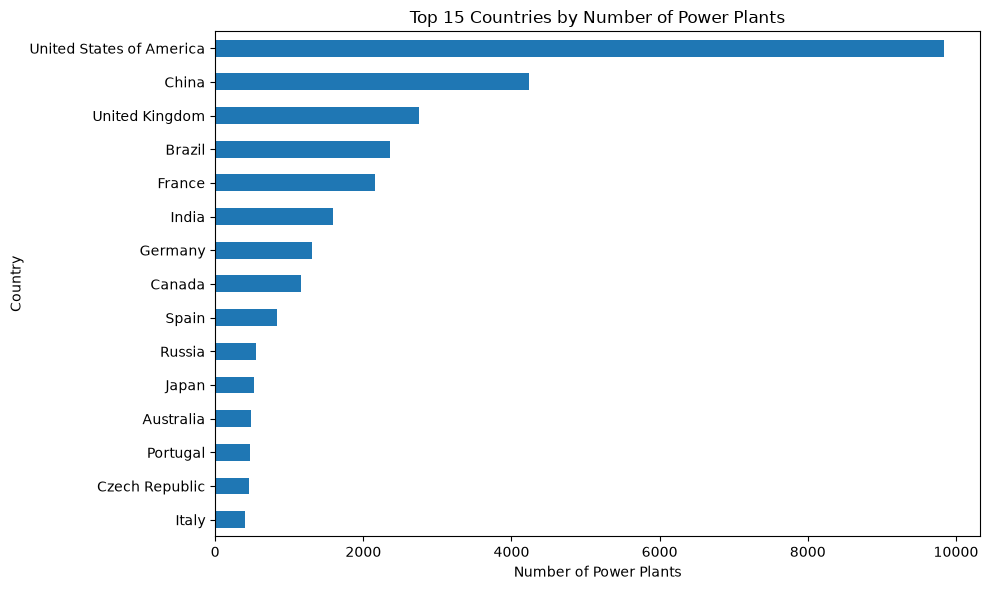

In [34]:
plt.figure(figsize=(10, 6))

top_15_countries.sort_values().plot(kind="barh")

plt.title("Top 15 Countries by Number of Power Plants")
plt.xlabel("Number of Power Plants")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

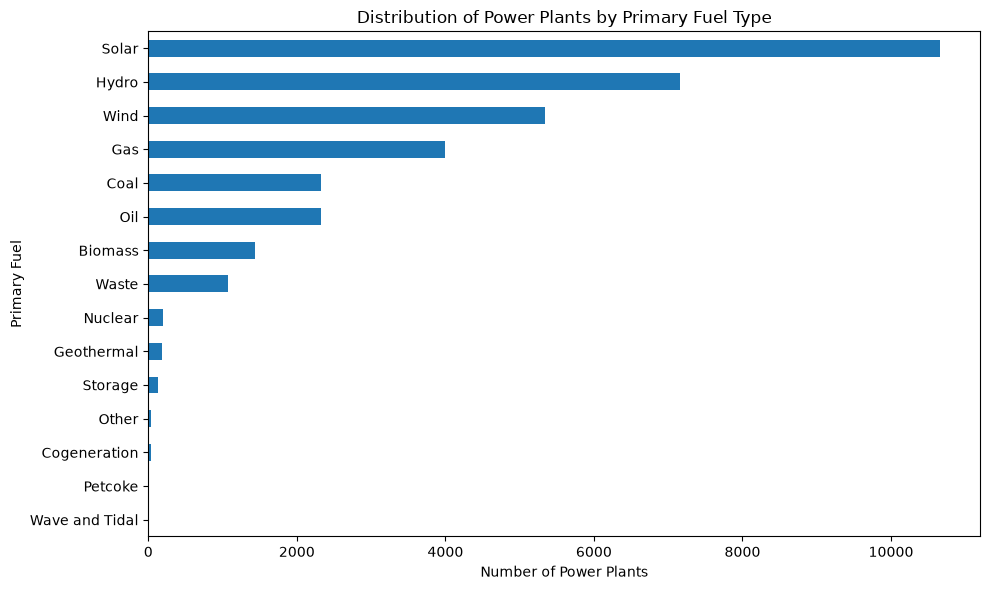

In [35]:
plt.figure(figsize=(10, 6))

fuel_counts.sort_values().plot(kind="barh")

plt.title("Distribution of Power Plants by Primary Fuel Type")
plt.xlabel("Number of Power Plants")
plt.ylabel("Primary Fuel")

plt.tight_layout()
plt.show()

### EDA Findings

The exploratory analysis highlighted several characteristics of the global power plant dataset.

The distribution of power plants across countries is highly uneven. The United States has the largest number of recorded power plants in the dataset, followed by China and the United Kingdom.

The analysis of primary fuel types also shows that some energy sources are much more represented than others.

Summary statistics were calculated for all numerical variables using the mean, median, and standard deviation. In particular, `capacity_mw` shows a large difference between its mean and median, suggesting a positively skewed distribution where a relatively small number of very large power plants increase the average capacity.

These initial findings provide a basis for the following statistical analysis, where power plant capacity will be compared across different fuel types.

## Statistical Analysis

In [36]:
top_fuels = df["primary_fuel"].value_counts().index

fuel_stats = []

for fuel in top_fuels:
    capacities = df.loc[
        df["primary_fuel"] == fuel,
        "capacity_mw"
    ].to_numpy()

    fuel_stats.append({
        "fuel_type": fuel,
        "count": len(capacities),
        "mean_capacity": np.mean(capacities),
        "median_capacity": np.median(capacities),
        "std_capacity": np.std(capacities)
    })

fuel_stats_df = pd.DataFrame(fuel_stats).set_index("fuel_type").round(2)

fuel_stats_df

,count,mean_capacity,median_capacity,std_capacity
fuel_type,,,,
Solar,10665,17.66,5.80,41.94
Hydro,7156,147.17,20.00,549.77
Wind,5344,49.22,27.00,106.13
Gas,3998,373.45,147.50,560.86
Coal,2330,843.58,600.00,888.00
Oil,2320,112.88,9.00,391.92
Biomass,1430,23.97,9.45,39.45
Waste,1068,13.81,4.80,20.57
Nuclear,195,2091.86,1888.00,1300.16


### Capacity Analysis by Fuel Type

The descriptive statistics show clear differences in installed capacity across fuel types.

Nuclear power plants have by far the highest capacities, with an average capacity of about 2,091 MW and a median of 1,888 MW. Coal plants also show relatively high capacities, with a mean of about 844 MW and a median of 600 MW, followed by gas plants with an average capacity of about 373 MW.

In contrast, fuel types such as Solar, Waste, Biomass, and Storage have much lower average and median capacities. For example, Solar has a mean capacity of only about 18 MW and a median of 5.8 MW.

For several fuel types, the mean is considerably higher than the median. This is particularly visible for Hydro, Oil, Gas, Petcoke, and Wave and Tidal, suggesting positively skewed distributions where a relatively small number of very large plants increase the average capacity.

The standard deviation also varies substantially across fuel types. Nuclear, Coal, Gas, and Hydro show particularly high variability in plant capacity, while categories such as Solar, Biomass, and Waste are more concentrated around smaller capacity values.

The number of observations also differs strongly between fuel types. Solar, Hydro, Wind, Gas, and Coal contain thousands of power plants, while categories such as Petcoke and Wave and Tidal contain very few observations. This difference in group size should be considered when interpreting the statistical comparison.

Overall, the descriptive analysis suggests that installed capacity differs substantially across fuel types, which supports performing further hypothesis testing to determine whether these differences in mean capacity are statistically significant.

### Hypothesis Testing

The descriptive statistics show substantial differences in installed capacity across fuel types. Some categories also show large differences between their mean and median capacities, as well as high standard deviations.

To determine whether the differences in mean installed capacity across fuel types are statistically significant, a one-way ANOVA will be performed.

**H0:** Mean installed capacity is equal across fuel types.  
**H1:** At least one fuel type has a different mean installed capacity.

In [37]:
fuel_groups = []

for fuel in df["primary_fuel"].unique():
    capacities = df.loc[
        df["primary_fuel"] == fuel,
        "capacity_mw"
    ].to_numpy()

    fuel_groups.append(capacities)

In [38]:
len(fuel_groups)

15

In [39]:
[len(group) for group in fuel_groups]

[7156,
 10665,
 3998,
 43,
 2320,
 5344,
 195,
 2330,
 1068,
 1430,
 10,
 12,
 189,
 135,
 41]

In [41]:
from scipy.stats import f_oneway

In [42]:
f_statistic, p_value = f_oneway(*fuel_groups)

print("F-statistic:", f_statistic)
print("p-value:", p_value)

F-statistic: 967.4600353089305
p-value: 0.0


### ANOVA Results

A one-way ANOVA was performed to determine whether mean installed capacity differs across primary fuel types.

**H0:** Mean installed capacity is equal across fuel types.  
**H1:** At least one fuel type has a different mean installed capacity.

The ANOVA returned an F-statistic of approximately **967.46** and a p-value extremely close to zero.

Since the p-value is well below the significance level of 0.05, the null hypothesis is rejected.

This result indicates that there is a statistically significant difference in mean installed capacity across fuel types. However, the ANOVA does not identify which specific fuel types differ from one another.

The result should be interpreted with some caution, as the fuel groups differ considerably in size and several capacity distributions are highly skewed with unequal variability.

## Time Series Analysis


In [43]:
time_df = df[df["commissioning_year"].notna()].copy()

In [44]:
time_df["commissioning_decade"] = (
    np.floor(time_df["commissioning_year"] / 10) * 10
).astype(int)

In [45]:
time_df[
    ["commissioning_year", "commissioning_decade"]
].head(10)

,commissioning_year,commissioning_decade
9,1965.0,1960
10,1978.0,1970
11,1985.0,1980
12,1951.0,1950
13,1963.0,1960
14,1958.0,1950
15,1971.0,1970
25,2010.0,2010
27,2010.0,2010
29,1980.0,1980


In [46]:
plants_by_decade = (
    time_df["commissioning_decade"]
    .value_counts()
    .sort_index()
)

plants_by_decade

commissioning_decade
1890       2
1900      68
1910     144
1920     288
1930     189
1940     227
1950     551
1960     786
1970     952
1980    1455
1990    1628
2000    3855
2010    7152
2020     150
Name: count, dtype: int64

In [47]:
time_df["commissioning_year"].max()

np.float64(2020.0)

The apparent decline in the 2020s should not be interpreted as a real downward trend, as the decade is only partially represented in the dataset.

In [49]:
complete_decades = plants_by_decade[
    (plants_by_decade.index >= 1900) &
    (plants_by_decade.index < 2020)
]

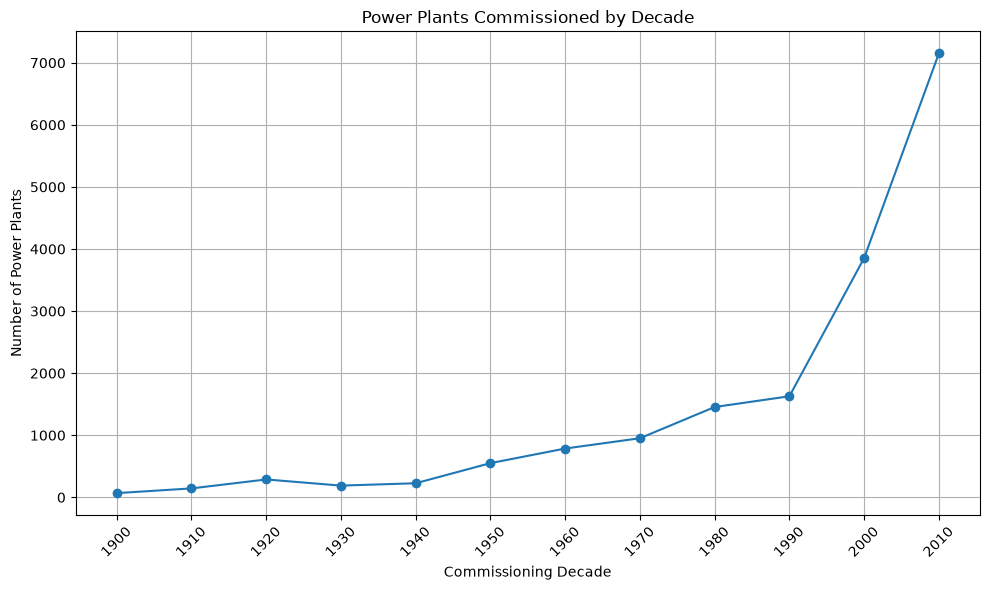

In [50]:
plt.figure(figsize=(10, 6))

plt.plot(
    complete_decades.index,
    complete_decades.values,
    marker="o"
)

plt.title("Power Plants Commissioned by Decade")
plt.xlabel("Commissioning Decade")
plt.ylabel("Number of Power Plants")

plt.xticks(complete_decades.index, rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

### Commissioning Trends Over Time

The number of commissioned power plants generally increases over time, with particularly strong growth from the 1990s through the 2010s.

The earliest decade (1890s) and the 2020s are only partially represented in the dataset. Since the earliest commissioning year is 1896 and the latest available year is 2020, these two incomplete decades were excluded from the trend visualization to allow a more consistent comparison between complete decades.

In [51]:
fuel_by_decade = pd.crosstab(
    time_df["commissioning_decade"],
    time_df["primary_fuel"]
)

fuel_by_decade

primary_fuel,Biomass,Coal,Cogeneration,Gas,Geothermal,Hydro,Nuclear,Oil,Other,Petcoke,Solar,Storage,Waste,Wind
commissioning_decade,,,,,,,,,,,,,,
1890,0,0,0,0,0,2,0,0,0,0,0,0,0,0
1900,1,1,0,1,0,62,0,3,0,0,0,0,0,0
1910,0,1,0,2,0,141,0,0,0,0,0,0,0,0
1920,0,4,0,3,0,279,0,1,1,0,0,0,0,0
1930,0,7,0,23,0,157,0,2,0,0,0,0,0,0
1940,1,10,0,23,0,187,0,3,1,0,0,0,2,0
1950,5,46,2,76,0,390,0,22,3,1,0,0,6,0
1960,20,105,1,142,3,402,1,104,2,0,0,0,6,0
1970,28,176,3,220,7,283,34,188,0,2,0,0,10,1


In [52]:
fuel_mix = pd.crosstab(
    time_df["commissioning_decade"],
    time_df["primary_fuel"],
    normalize="index"
) * 100

In [53]:
fuel_mix_complete = fuel_mix[
    (fuel_mix.index >= 1900) &
    (fuel_mix.index < 2020)
]

fuel_mix_complete.round(1)

primary_fuel,Biomass,Coal,Cogeneration,Gas,Geothermal,Hydro,Nuclear,Oil,Other,Petcoke,Solar,Storage,Waste,Wind
commissioning_decade,,,,,,,,,,,,,,
1900,1.5,1.5,0.0,1.5,0.0,91.2,0.0,4.4,0.0,0.0,0.0,0.0,0.0,0.0
1910,0.0,0.7,0.0,1.4,0.0,97.9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1920,0.0,1.4,0.0,1.0,0.0,96.9,0.0,0.3,0.3,0.0,0.0,0.0,0.0,0.0
1930,0.0,3.7,0.0,12.2,0.0,83.1,0.0,1.1,0.0,0.0,0.0,0.0,0.0,0.0
1940,0.4,4.4,0.0,10.1,0.0,82.4,0.0,1.3,0.4,0.0,0.0,0.0,0.9,0.0
1950,0.9,8.3,0.4,13.8,0.0,70.8,0.0,4.0,0.5,0.2,0.0,0.0,1.1,0.0
1960,2.5,13.4,0.1,18.1,0.4,51.1,0.1,13.2,0.3,0.0,0.0,0.0,0.8,0.0
1970,2.9,18.5,0.3,23.1,0.7,29.7,3.6,19.7,0.0,0.2,0.0,0.0,1.1,0.1
1980,3.5,14.0,0.5,19.2,1.9,36.8,3.3,10.7,0.3,0.4,0.3,0.0,7.1,1.9


### Evolution of the Fuel Mix

The fuel mix of newly commissioned power plants changed substantially over time.

Hydropower dominated the early decades of the dataset, representing more than 90% of recorded plants commissioned during the first decades of the 20th century.

From the mid-20th century, the mix became increasingly diversified as gas, coal, and oil gained importance. By the 1970s, no single fuel type represented a majority of newly commissioned plants.

Renewable technologies became increasingly important in more recent decades. Wind represented approximately 23% of plants commissioned in the 2000s, while solar increased dramatically in the 2010s, accounting for about 46% of newly commissioned plants in that decade.

Overall, the data suggests a long-term shift from a hydro-dominated system toward a more diversified mix, followed by strong growth in wind and solar technologies.

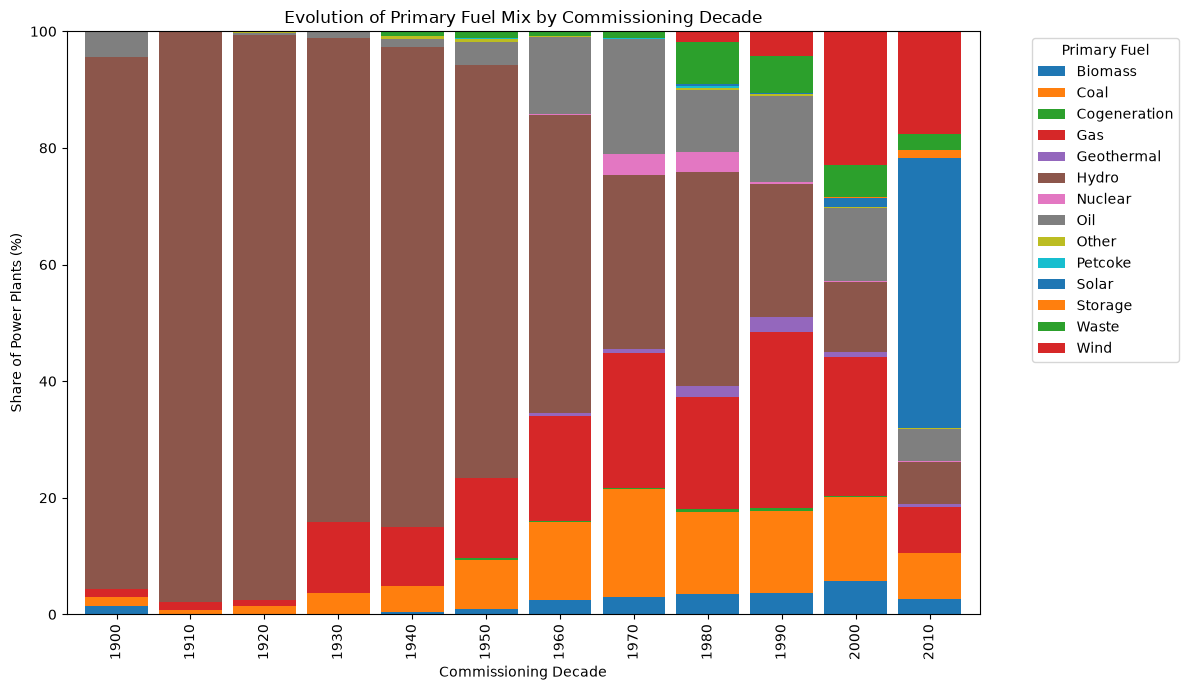

In [54]:
fuel_mix_complete.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 7),
    width=0.85
)

plt.title("Evolution of Primary Fuel Mix by Commissioning Decade")
plt.xlabel("Commissioning Decade")
plt.ylabel("Share of Power Plants (%)")

plt.ylim(0, 100)

plt.legend(
    title="Primary Fuel",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

## Advanced Visualization

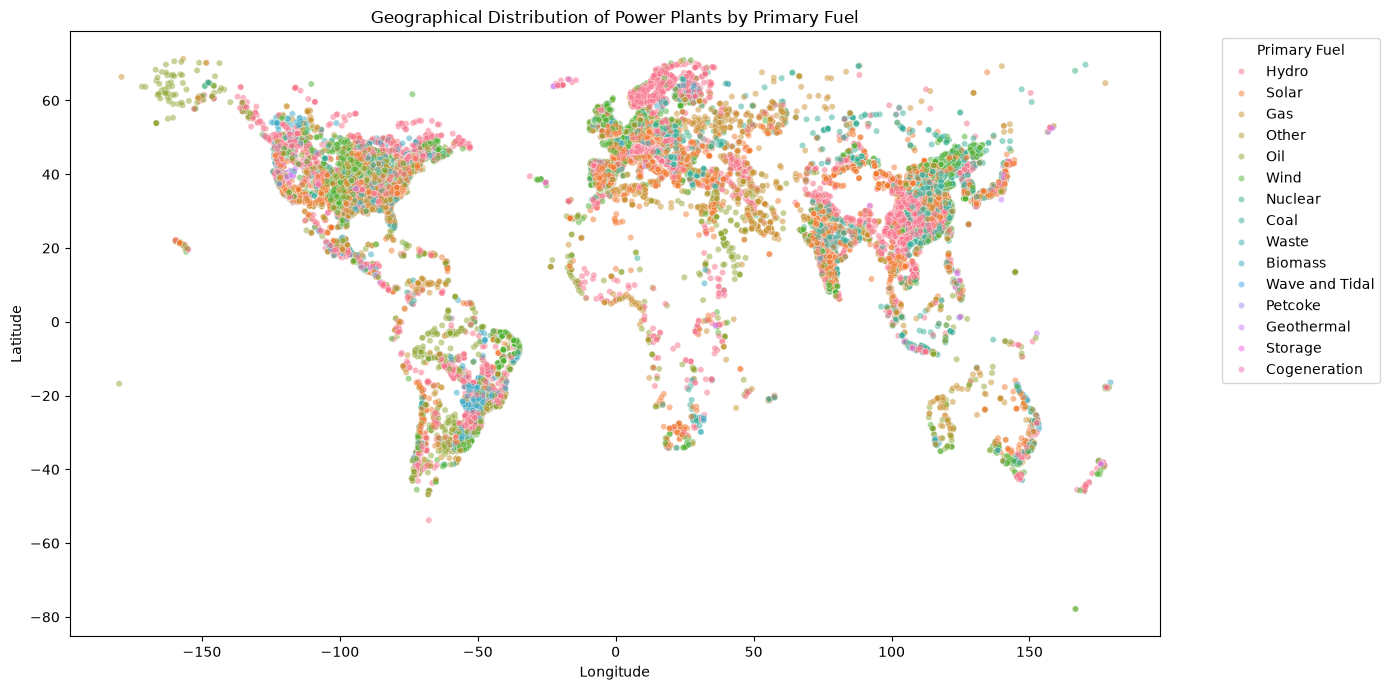

In [55]:
plt.figure(figsize=(14, 7))

sns.scatterplot(
    data=df,
    x="longitude",
    y="latitude",
    hue="primary_fuel",
    alpha=0.5,
    s=20
)

plt.title("Geographical Distribution of Power Plants by Primary Fuel")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.legend(
    title="Primary Fuel",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

### Geographical Distribution

The geographical scatter plot shows that power plants in the dataset are distributed across most populated regions of the world, with particularly high concentrations in North America, Europe, and parts of Asia.

Different primary fuel types are represented across regions, although the large number of fuel categories and overlapping observations make this visualization more suitable for identifying broad geographical patterns than for comparing individual fuel types precisely.

Overall, the visualization highlights both the global coverage of the dataset and the strong concentration of power plants in specific regions.

## Matrix Operations in Real-World Context

In [61]:
top_5_fuels = df["primary_fuel"].value_counts().head(5).index

In [62]:
matrix_df = df[
    ["capacity_mw", "latitude", "longitude", "primary_fuel"]
].copy()

In [63]:
matrix_df = matrix_df[
    matrix_df["primary_fuel"].isin(top_5_fuels)
]

In [64]:
matrix_df = pd.get_dummies(
    matrix_df,
    columns=["primary_fuel"]
)

In [65]:
matrix_df.head()

,capacity_mw,latitude,longitude,primary_fuel_Coal,primary_fuel_Gas,primary_fuel_Hydro,primary_fuel_Solar,primary_fuel_Wind
0,33.0,32.322,65.1190,False,False,True,False,False
1,10.0,31.670,65.7950,False,False,False,True,False
2,10.0,31.623,65.7920,False,False,False,True,False
3,66.0,34.556,69.4787,False,False,True,False,False
4,100.0,34.641,69.7170,False,False,True,False,False


In [66]:
X = matrix_df.to_numpy(dtype=float)

X.shape

(29493, 8)

In [67]:
X_standardized = (
    X - np.mean(X, axis=0)
) / np.std(X, axis=0)

In [68]:
correlation_matrix = np.corrcoef(
    X_standardized,
    rowvar=False
)

In [69]:
correlation_df = pd.DataFrame(
    correlation_matrix,
    index=matrix_df.columns,
    columns=matrix_df.columns
)

correlation_df.round(2)

,capacity_mw,latitude,longitude,primary_fuel_Coal,primary_fuel_Gas,primary_fuel_Hydro,primary_fuel_Solar,primary_fuel_Wind
capacity_mw,1.00,-0.05,0.14,0.41,0.17,-0.02,-0.23,-0.12
latitude,-0.05,1.00,-0.10,-0.02,-0.05,-0.12,0.12,0.05
longitude,0.14,-0.10,1.00,0.23,-0.12,-0.03,0.00,-0.03
primary_fuel_Coal,0.41,-0.02,0.23,1.00,-0.12,-0.17,-0.22,-0.14
primary_fuel_Gas,0.17,-0.05,-0.12,-0.12,1.00,-0.22,-0.30,-0.19
primary_fuel_Hydro,-0.02,-0.12,-0.03,-0.17,-0.22,1.00,-0.43,-0.27
primary_fuel_Solar,-0.23,0.12,0.00,-0.22,-0.30,-0.43,1.00,-0.35
primary_fuel_Wind,-0.12,0.05,-0.03,-0.14,-0.19,-0.27,-0.35,1.00


### Correlation Analysis

The correlation matrix shows that installed capacity has its strongest positive association with coal power plants (0.41), while solar power plants show a negative association with capacity (-0.23). This is consistent with the earlier descriptive analysis, where coal plants had considerably larger average capacities than solar plants.

Latitude and longitude show only weak correlations with installed capacity, suggesting that geographical coordinates alone have little linear relationship with plant capacity.

Negative correlations between fuel dummy variables should be interpreted cautiously because the variables were created using one-hot encoding. Since each power plant has only one primary fuel type, a value of 1 for one fuel automatically implies 0 for the others.

In [70]:
eigenvalues, eigenvectors = np.linalg.eigh(correlation_matrix)

In [71]:
order = np.argsort(eigenvalues)[::-1]

eigenvalues = eigenvalues[order]
eigenvectors = eigenvectors[:, order]

eigenvalues

array([ 1.72893408e+00,  1.43959880e+00,  1.29242128e+00,  1.24082777e+00,
        9.78534667e-01,  7.58033025e-01,  5.61650381e-01, -2.34630565e-13])

In [72]:
explained_variance = eigenvalues / eigenvalues.sum() * 100

explained_variance

array([ 2.16116760e+01,  1.79949850e+01,  1.61552660e+01,  1.55103472e+01,
        1.22316833e+01,  9.47541281e+00,  7.02062976e+00, -2.93288206e-12])

In [73]:
cumulative_variance = np.cumsum(explained_variance)

cumulative_variance

array([ 21.611676  ,  39.60666096,  55.76192691,  71.27227409,
        83.50395743,  92.97937024, 100.        , 100.        ])

### Eigenvalues and Eigenvectors

Eigenvalue decomposition was applied to the correlation matrix to examine the main directions of variation across plant capacity, geographical location, and primary fuel indicators.

The largest eigenvalue explains approximately 21.6% of the total variance, while the first four components together explain about 71.3%.

The final eigenvalue is effectively zero, which is expected because the one-hot encoded fuel variables are linearly dependent: for each power plant, exactly one of the five selected primary fuel indicators is equal to 1.

Eigenvectors represent combinations of the original variables that define these principal directions of variation. This concept is closely related to Principal Component Analysis (PCA), where eigenvalues indicate how much information each component captures.

## Integrating NumPy with Pandas and Matplotlib

In [74]:
mean_capacity = np.mean(df["capacity_mw"].to_numpy())

In [75]:
high_capacity_plants = df[
    df["capacity_mw"].to_numpy() > mean_capacity
]

high_capacity_plants.head()

,country,country_long,name,gppd_idnr,capacity_mw,latitude,longitude,primary_fuel,other_fuel1,other_fuel2,...,estimated_generation_gwh_2013,estimated_generation_gwh_2014,estimated_generation_gwh_2015,estimated_generation_gwh_2016,estimated_generation_gwh_2017,estimated_generation_note_2013,estimated_generation_note_2014,estimated_generation_note_2015,estimated_generation_note_2016,estimated_generation_note_2017
10,ALB,Albania,Fierza,WRI1002170,500.0,42.2514,20.0431,Hydro,NaN,NaN,...,1976.01,1276.61,1503.72,1795.15,1648.24,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
11,ALB,Albania,Koman,WRI1002171,600.0,42.1033,19.8224,Hydro,NaN,NaN,...,2072.13,1618.73,1805.63,2434.84,1982.72,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
15,ALB,Albania,Vau i Dijes,WRI1002175,250.0,42.0137,19.6359,Hydro,NaN,NaN,...,895.02,561.94,614.47,897.47,703.64,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
19,DZA,Algeria,Ain Djasser,WRI1023776,520.0,35.8665,6.0262,Gas,Oil,NaN,...,NaN,NaN,NaN,NaN,2171.28,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,CAPACITY-FACTOR-V1
27,DZA,Algeria,Arbaa,WRI1023777,560.0,36.5988,3.1375,Gas,Oil,NaN,...,NaN,NaN,NaN,NaN,2338.30,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,CAPACITY-FACTOR-V1


In [76]:
len(high_capacity_plants)

5906

In [77]:
fuel_names = fuel_stats_df.index.to_numpy()
mean_capacities = fuel_stats_df["mean_capacity"].to_numpy()

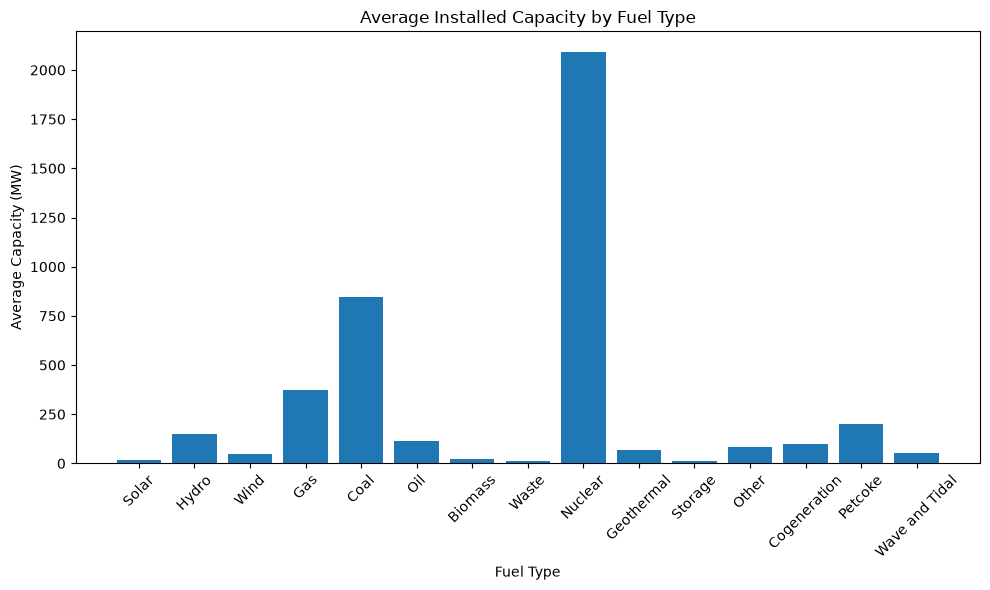

In [78]:
plt.figure(figsize=(10, 6))

plt.bar(
    fuel_names,
    mean_capacities
)

plt.title("Average Installed Capacity by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Average Capacity (MW)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Integrating NumPy, Pandas and Matplotlib

Throughout the analysis, NumPy was used together with Pandas and Matplotlib to support numerical computation, filtering, and visualization.

NumPy arrays were used to calculate statistical measures, prepare fuel-specific capacity groups, standardize numerical features, compute correlation matrices, and perform eigenvalue decomposition.

NumPy was also used to create boolean conditions for filtering Pandas DataFrames and to convert Pandas results into arrays that could be passed directly to Matplotlib for visualization.

This workflow demonstrates how NumPy provides the numerical foundation, Pandas organizes and manipulates the dataset, and Matplotlib communicates the results visually.

## ## Final Conclusion

This analysis explored the Global Power Plant Database using NumPy, Pandas, Matplotlib, Seaborn, and statistical methods.

The dataset contains 34,936 power plants distributed across many countries and fuel types. The United States has the largest number of recorded power plants in the dataset, followed by China and the United Kingdom. Solar, Hydro, Wind, Gas, and Coal are among the most represented primary fuel types.

Installed capacity varies considerably across fuel technologies. 
Nuclear power plants stand out particularly strongly in the capacity analysis. Although Nuclear represents only 195 plants in the dataset, it has by far the highest mean capacity (approximately 2,092 MW) and a median capacity of 1,888 MW. The high median indicates that this result is not simply caused by a small number of extreme plants: nuclear plants in the dataset are generally much larger in installed capacity than plants using other primary fuel types.
Followed by Coal at approximately 844 MW and Gas at approximately 373 MW. In contrast, Solar plants have a much lower average capacity of approximately 18 MW. Large differences between mean and median capacity for several fuel types also revealed strongly skewed distributions and substantial variation in plant size.

A one-way ANOVA was performed to test whether mean installed capacity differs across fuel types. The test produced an F-statistic of approximately 967.46 and a p-value extremely close to zero. The null hypothesis was therefore rejected, providing strong statistical evidence that mean installed capacity differs across fuel types.

The time-series analysis also revealed a major evolution in the composition of newly commissioned power plants. Hydropower dominated the early decades of the dataset, accounting for more than 90% of recorded plants in several early 20th-century decades. The mix gradually diversified as Coal, Gas, and Oil became more important. More recently, renewable technologies expanded strongly: Wind represented approximately 23% of plants commissioned in the 2000s, while Solar accounted for approximately 46% in the 2010s.

The geographical analysis showed that power plants are distributed across most populated regions of the world, with particularly dense concentrations in North America, Europe, and Asia. The geographical scatter plot also demonstrated how fuel technologies vary across different regions.

Finally, matrix operations were used to examine relationships between installed capacity, geographical coordinates, and fuel-type indicators. Coal showed the strongest positive correlation with installed capacity among the selected fuel types, while latitude and longitude had relatively weak linear relationships with capacity. Eigenvalue decomposition showed that the first four components captured approximately 71% of the variation in the selected numerical representation.

Overall, the project demonstrates how NumPy can provide efficient numerical and matrix operations, Pandas can support data cleaning, aggregation, and exploration, and Matplotlib and Seaborn can transform analytical results into interpretable visualizations. The analysis highlights significant differences between power-generation technologies and a clear long-term shift in the composition of newly commissioned plants toward Wind and Solar.